In [2]:
# %load_ext autoreload
# %autoreload 2

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from pathlib import Path
from typing import Tuple, List, Set

# Add project root to sys.path
project_root = Path('..').resolve()
sys.path.append(str(project_root))

# Import project modules
from src.data_loader.cmapss.CMAPSSDataLoader import CMAPSSDataLoader
from src.data_loader.cmapss.CMAPSSTimeSeriesDataset import CMAPSSTimeSeriesDataset
from src.data_loader.cmapss.CMAPSSDatasetWrapper import CMAPSSDatasetWrapper
from src.models.TransformerModel import TransformerModel
from src.models.LSTMModel import LSTMModel
from src.counterfactuals.core import BasisGenerator  
from src.counterfactuals.basis import BSplineBasis

from src.data_loader.cmapss.CMAPSSTorchDataloader import CMAPSSTorchDataloader

from torch.utils.data import DataLoader

from src.counterfactuals.utils.cmapss.load_data import load_and_preprocess_data
from src.counterfactuals.utils.cmapss.cf_utils import get_unit_sequences, predict_rul, get_valid_target_rul, get_last_sequence


# Device config
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device("cpu")
print(f"Using device: {device}")

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)


Using device: cpu


# Load Data

In [3]:
dataloader = CMAPSSTorchDataloader()
data_subset = 'FD001'

train_loader, val_loader, test_loader, preprocess, train_norm, test_norm, val_norm = load_and_preprocess_data(
            subset="FD001",
            seq_len=50,
            max_rul=125,
            batch_size=32,
            seed=42,
            val_ratio=0.2,
            var_threshold=0.01,
        )

feature_cols = preprocess['feature_cols']


Loading + Preprocessing FD001
Loaded FD001:
  Training samples: 20631, Units: 100
  Test samples: 13096, Units: 100
Removed 10 low-variance features: ['setting_1', 'setting_2', 'setting_3', 'sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Kept 14 features

Final feature_dim = 14
Train batches = 402 | Val batches = 90 | Test batches = 3


# Check the data dist

In [4]:
# Quick sanity check: label distributions
import numpy as np

train_labels = []
for _, y in train_loader:
    train_labels.extend(y.numpy().flatten().tolist())

val_labels = []
for _, y in val_loader:
    val_labels.extend(y.numpy().flatten().tolist())

train_labels = np.array(train_labels)
val_labels = np.array(val_labels)

print(f"\n{'='*60}")
print("LABEL DISTRIBUTION SANITY CHECK")
print(f"{'='*60}")
print(f"  Train labels — min: {train_labels.min():.4f}, max: {train_labels.max():.4f}, "
      f"mean: {train_labels.mean():.4f}, std: {train_labels.std():.4f}")
print(f"  Val   labels — min: {val_labels.min():.4f}, max: {val_labels.max():.4f}, "
      f"mean: {val_labels.mean():.4f}, std: {val_labels.std():.4f}")
print(f"{'='*60}\n")


LABEL DISTRIBUTION SANITY CHECK
  Train labels — min: 0.0000, max: 125.0000, mean: 76.3899, std: 41.5680
  Val   labels — min: 0.0000, max: 125.0000, mean: 70.5947, std: 40.2492



# Load the Model

In [5]:
sequence_length = 50
input_size = len(feature_cols)

model = TransformerModel(
    input_size=input_size,
    d_model=128,
    nhead=4,
    num_layers=2,
    dim_feedforward=256,
    dropout=0.2
).to(device)

model_path = '/home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel/outputs/saved_models/transformer_best_last.pth'
model_checkpoint_path = '/home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel/outputs/saved_models/transformer_best_last.ckpt'

if os.path.exists(model_path):
    try:
        checkpoint = torch.load(model_checkpoint_path, map_location=device)
        print(f"{checkpoint.keys()}")
        model.load_state_dict(checkpoint['model_state_dict'], strict=False)
        print(f"✅ Loaded model from {model_path}")
    except Exception as e:
        print(f"⚠️ Model load failed: {e}")
        raise
else:
    print(f"⚠️ Model file not found at {model_path}. Please ensure the model is trained and saved correctly.")

model.eval()
#print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")


dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'best_score', 'best_epoch', 'history', 'config', 'preprocess'])
✅ Loaded model from /home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel/outputs/saved_models/transformer_best_last.pth

Total parameters: 275,201


In [6]:
import json

scaler_path = '../outputs/preprocess.json'

if os.path.exists(scaler_path):
    with open(scaler_path, 'r') as f:
        scaler_data = json.load(f)
    norm_stats = {
        'mean': np.array([scaler_data['mean'][col] for col in feature_cols]),
        'std': np.array([scaler_data['std'][col] for col in feature_cols])
    }
    print(f"✅ Loaded normalization stats from {scaler_path}")
else:
    # Use stats from current normalization
    norm_stats = {
        'mean': preprocess['mean'],
        'std': preprocess['std']
    }
    print("⚠️ Using normalization stats from current run")

✅ Loaded normalization stats from ../outputs/preprocess.json


In [8]:
## Basis Generators
generator_fourier = BasisGenerator(
        model=model,
        sequence_length=sequence_length,
        feature_dim=input_size,
        basis_type='fourier',
        num_basis=10,
        device=device,
        normalization_stats=norm_stats
    )

generator_bspline = BasisGenerator(
        model=model,
        sequence_length=sequence_length,
        feature_dim=input_size,
        basis_type='bspline',
        num_basis=10,
        device=device,
        normalization_stats=norm_stats
    )

generator_wavelet = BasisGenerator(
        model=model,
        sequence_length=sequence_length,
        feature_dim=input_size,
        basis_type='wavelet',
        num_basis=10,
        device=device,
        normalization_stats=norm_stats
    )

generator_polynomial = BasisGenerator(
        model=model,
        sequence_length=sequence_length,
        feature_dim=input_size,
        basis_type='polynomial',
        num_basis=10,
        device=device,
        normalization_stats=norm_stats
    )

generator_rbf = BasisGenerator(
        model=model,
        sequence_length=sequence_length,
        feature_dim=input_size,
        basis_type='rbf',
        num_basis=10,
        device=device,
        normalization_stats=norm_stats
    )

generators = {"fourier":generator_fourier, 
              "bspline":generator_bspline, 
              "wavelet":generator_wavelet, 
              "polynomial":generator_polynomial, 
              "rbf":generator_rbf
            }

print("\n✅ Basis generators initialized successfully")


✅ Basis generators initialized successfully


In [9]:
# ── Cell: Batch generation across ALL generators × ALL test units ──

all_test_unit_ids = sorted(test_norm['unit_id'].unique().astype(int).tolist())
print(f"Total test units: {len(all_test_unit_ids)}")

all_results = {}        # generator_name -> DataFrame
all_cfs_dict = {}       # generator_name -> {unit_id: (original, cf_tensor, target_rul, current_pred, true_rul)}

for gen_name, gen in generators.items():
    print(f"\n{'='*80}")
    print(f"  Generator: {gen_name.upper()}")
    print(f"{'='*80}")
    
    gen_results = []
    gen_cfs = {}
    
    for unit_id in all_test_unit_ids:
        query_seq, true_rul = get_last_sequence(test_norm, unit_id, sequence_length, feature_cols)
        
        if query_seq is None:
            continue
        
        query_instance = torch.tensor(query_seq, dtype=torch.float32).to(device)
        
        try:
            current_pred = predict_rul(model, query_seq, device)
            target_rul = get_valid_target_rul(current_pred, increase_range=(10, 30), max_rul=125)
            
            cfs = gen.generate(
                query_instance=query_instance,
                target_rul=target_rul,
                num_cfs=1,
                lr=0.001,
                max_iter=1000,
                lambdas={
                    'validity': 10.0,
                    'prox': 9.0,
                    'sparsity': 0.5,
                    'diversity': 0.0,
                    'smoothness': 1.3,
                },
                verbose=False
            )
            
            cf_numpy = cfs[0].detach().cpu().numpy()
            cf_pred = predict_rul(model, cf_numpy, device)
            
            # Proximity: mean absolute change per feature
            delta = np.abs(cf_numpy - query_seq)
            mean_delta = delta.mean()
            max_delta = delta.max()
            l2_dist = np.sqrt(np.sum((cf_numpy - query_seq) ** 2))
            
            # Sparsity: fraction of features with negligible change
            feature_changes = np.mean(np.abs(cf_numpy - query_seq), axis=0)  # (D,)
            sparsity = np.mean(feature_changes < 0.01)  # fraction of "unchanged" features
            
            error = abs(cf_pred - target_rul)
            
            gen_results.append({
                'unit_id': unit_id,
                'true_rul': true_rul,
                'original_pred': current_pred,
                'target_rul': target_rul,
                'cf_pred': cf_pred,
                'error': error,
                'success': error < 10.0,
                'mean_delta': mean_delta,
                'max_delta': max_delta,
                'l2_distance': l2_dist,
                'sparsity': sparsity,
            })
            
            gen_cfs[unit_id] = {
                'original': query_seq,
                'cf': cf_numpy,
                'target_rul': target_rul,
                'current_pred': current_pred,
                'cf_pred': cf_pred,
                'true_rul': true_rul,
            }
            
        except Exception as e:
            print(f"  ⚠️ Failed for unit {unit_id} ({gen_name}): {e}")
    
    df = pd.DataFrame(gen_results)
    all_results[gen_name] = df
    all_cfs_dict[gen_name] = gen_cfs
    
    success_rate = df['success'].mean() * 100 if len(df) > 0 else 0
    mean_error = df['error'].mean() if len(df) > 0 else float('nan')
    print(f"  ✅ {gen_name}: {len(df)} units | Success={success_rate:.1f}% | Mean Error={mean_error:.2f}")

print(f"\n{'='*80}")
print("All generators finished.")

Total test units: 100

  Generator: FOURIER
⚠️ Current RUL (123.2) is close to max. Target adjusted to 125.0
⚠️ Current RUL (127.0) is close to max. Target adjusted to 125.0
⚠️ Current RUL (124.3) is close to max. Target adjusted to 125.0
⚠️ Current RUL (116.6) is close to max. Target adjusted to 125.0
⚠️ Current RUL (129.1) is close to max. Target adjusted to 125.0
⚠️ Current RUL (119.0) is close to max. Target adjusted to 125.0
⚠️ Current RUL (116.5) is close to max. Target adjusted to 125.0
⚠️ Current RUL (130.3) is close to max. Target adjusted to 125.0
⚠️ Current RUL (122.5) is close to max. Target adjusted to 125.0
⚠️ Current RUL (120.9) is close to max. Target adjusted to 125.0
⚠️ Current RUL (126.8) is close to max. Target adjusted to 125.0
⚠️ Current RUL (127.7) is close to max. Target adjusted to 125.0
⚠️ Current RUL (125.4) is close to max. Target adjusted to 125.0
⚠️ Current RUL (131.6) is close to max. Target adjusted to 125.0
⚠️ Current RUL (129.6) is close to max. Target

In [19]:
# ── Cell: Batch generation across ALL generators × ALL TRAINING units ──

all_train_unit_ids = sorted(train_norm['unit_id'].unique().astype(int).tolist())
print(f"Total training units: {len(all_train_unit_ids)}")

all_train_results = {}        # generator_name -> DataFrame
all_train_cfs_dict = {}       # generator_name -> {unit_id: {...}}

for gen_name, gen in generators.items():
    print(f"\n{'='*80}")
    print(f"  Generator: {gen_name.upper()} (TRAINING SET)")
    print(f"{'='*80}")
    
    gen_results = []
    gen_cfs = {}
    
    for unit_id in all_train_unit_ids:
        # Get all sequences for this training unit
        train_sequences, train_ruls, train_cycles = get_unit_sequences(
            train_norm, unit_id, sequence_length, feature_cols
        )
        
        if len(train_sequences) == 0:
            continue
        
        # Select mid-life sequence (not too early, not too late)
        mid_idx = len(train_sequences) // 2
        query_seq = train_sequences[mid_idx]
        true_rul = train_ruls[mid_idx]
        cycle_num = train_cycles[mid_idx]
        
        query_instance = torch.tensor(query_seq, dtype=torch.float32).to(device)
        
        try:
            current_pred = predict_rul(model, query_seq, device)
            target_rul = get_valid_target_rul(current_pred, increase_range=(10, 30), max_rul=125)
            
            cfs = gen.generate(
                query_instance=query_instance,
                target_rul=target_rul,
                num_cfs=1,
                lr=0.001,
                max_iter=1000,
                lambdas={
                    'validity': 10.0,
                    'prox': 9.0,
                    'sparsity': 0.5,
                    'diversity': 0.0,
                    'smoothness': 1.3,
                },
                verbose=False
            )
            
            cf_numpy = cfs[0].detach().cpu().numpy()
            cf_pred = predict_rul(model, cf_numpy, device)
            
            delta = np.abs(cf_numpy - query_seq)
            mean_delta = delta.mean()
            max_delta = delta.max()
            l2_dist = np.sqrt(np.sum((cf_numpy - query_seq) ** 2))
            
            feature_changes = np.mean(np.abs(cf_numpy - query_seq), axis=0)
            sparsity = np.mean(feature_changes < 0.01)
            
            error = abs(cf_pred - target_rul)
            
            gen_results.append({
                'unit_id': unit_id,
                'cycle': cycle_num,
                'true_rul': true_rul,
                'original_pred': current_pred,
                'target_rul': target_rul,
                'cf_pred': cf_pred,
                'error': error,
                'success': error < 10.0,
                'mean_delta': mean_delta,
                'max_delta': max_delta,
                'l2_distance': l2_dist,
                'sparsity': sparsity,
            })
            
            gen_cfs[unit_id] = {
                'original': query_seq,
                'cf': cf_numpy,
                'target_rul': target_rul,
                'current_pred': current_pred,
                'cf_pred': cf_pred,
                'true_rul': true_rul,
                'cycle': cycle_num,
            }
            
        except Exception as e:
            print(f"  ⚠️ Failed for unit {unit_id} ({gen_name}): {e}")
    
    df = pd.DataFrame(gen_results)
    all_train_results[gen_name] = df
    all_train_cfs_dict[gen_name] = gen_cfs
    
    success_rate = df['success'].mean() * 100 if len(df) > 0 else 0
    mean_error = df['error'].mean() if len(df) > 0 else float('nan')
    print(f"  ✅ {gen_name}: {len(df)} units | Success={success_rate:.1f}% | Mean Error={mean_error:.2f}")

print(f"\n{'='*80}")
print("All generators finished (TRAINING SET).")

Total training units: 80

  Generator: FOURIER (TRAINING SET)
⚠️ Current RUL (126.4) is close to max. Target adjusted to 125.0
⚠️ Current RUL (121.1) is close to max. Target adjusted to 125.0
⚠️ Current RUL (118.5) is close to max. Target adjusted to 125.0
⚠️ Current RUL (127.6) is close to max. Target adjusted to 125.0
⚠️ Current RUL (130.5) is close to max. Target adjusted to 125.0
⚠️ Current RUL (130.8) is close to max. Target adjusted to 125.0
⚠️ Current RUL (127.0) is close to max. Target adjusted to 125.0
⚠️ Current RUL (119.8) is close to max. Target adjusted to 125.0
⚠️ Current RUL (131.6) is close to max. Target adjusted to 125.0
⚠️ Current RUL (121.2) is close to max. Target adjusted to 125.0
⚠️ Current RUL (130.4) is close to max. Target adjusted to 125.0
  ✅ fourier: 80 units | Success=100.0% | Mean Error=0.57

  Generator: BSPLINE (TRAINING SET)
⚠️ Current RUL (126.4) is close to max. Target adjusted to 125.0
⚠️ Current RUL (121.1) is close to max. Target adjusted to 125.0

In [20]:
# ── Cell: Training set summary table ──

train_summary_rows = []
for gen_name, df in all_train_results.items():
    train_summary_rows.append({
        'Basis': gen_name,
        'Units': len(df),
        'Success Rate (%)': df['success'].mean() * 100,
        'Mean Error': df['error'].mean(),
        'Median Error': df['error'].median(),
        'Std Error': df['error'].std(),
        'Max Error': df['error'].max(),
        'Mean L2 Dist': df['l2_distance'].mean(),
        'Mean |Δ|': df['mean_delta'].mean(),
        'Max |Δ|': df['max_delta'].mean(),
        'Mean Sparsity': df['sparsity'].mean(),
    })

train_summary_df = pd.DataFrame(train_summary_rows).set_index('Basis')

# ── Side-by-side comparison: Test vs Train ──
print(f"\n{'='*90}")
print("  TEST vs TRAIN COMPARISON")
print(f"{'='*90}")
for gen_name in generators.keys():
    test_sr = all_results[gen_name]['success'].mean() * 100
    train_sr = all_train_results[gen_name]['success'].mean() * 100
    test_err = all_results[gen_name]['error'].mean()
    train_err = all_train_results[gen_name]['error'].mean()
    print(f"  {gen_name:<12} | Test: SR={test_sr:5.1f}%, Err={test_err:6.2f} | "
          f"Train: SR={train_sr:5.1f}%, Err={train_err:6.2f}")
print(f"{'='*90}")

train_summary_df.style.format({
    'Success Rate (%)': '{:.1f}',
    'Mean Error': '{:.2f}',
    'Median Error': '{:.2f}',
    'Std Error': '{:.2f}',
    'Max Error': '{:.2f}',
    'Mean L2 Dist': '{:.3f}',
    'Mean |Δ|': '{:.4f}',
    'Max |Δ|': '{:.4f}',
    'Mean Sparsity': '{:.3f}',
}).background_gradient(subset=['Success Rate (%)'], cmap='Greens') \
  .background_gradient(subset=['Mean Error'], cmap='Reds_r')


  TEST vs TRAIN COMPARISON
  fourier      | Test: SR=100.0%, Err=  0.61 | Train: SR=100.0%, Err=  0.57
  bspline      | Test: SR=100.0%, Err=  0.80 | Train: SR=100.0%, Err=  0.81
  wavelet      | Test: SR=100.0%, Err=  0.71 | Train: SR=100.0%, Err=  0.68
  polynomial   | Test: SR=100.0%, Err=  0.74 | Train: SR=100.0%, Err=  0.73
  rbf          | Test: SR=100.0%, Err=  0.68 | Train: SR=100.0%, Err=  0.69


,Units,Success Rate (%),Mean Error,Median Error,Std Error,Max Error,Mean L2 Dist,Mean |Δ|,Max |Δ|,Mean Sparsity
Basis,,,,,,,,,,
fourier,80,100.0,0.57,0.56,0.26,1.00,1.665,0.0499,0.1975,0.000
bspline,80,100.0,0.81,0.82,0.14,0.99,1.374,0.0480,0.0845,0.061
wavelet,80,100.0,0.68,0.73,0.23,0.99,2.776,0.0838,0.2768,0.003
polynomial,80,100.0,0.73,0.75,0.20,1.00,1.427,0.0422,0.2747,0.021
rbf,80,100.0,0.69,0.73,0.21,1.00,1.417,0.0495,0.0924,0.033


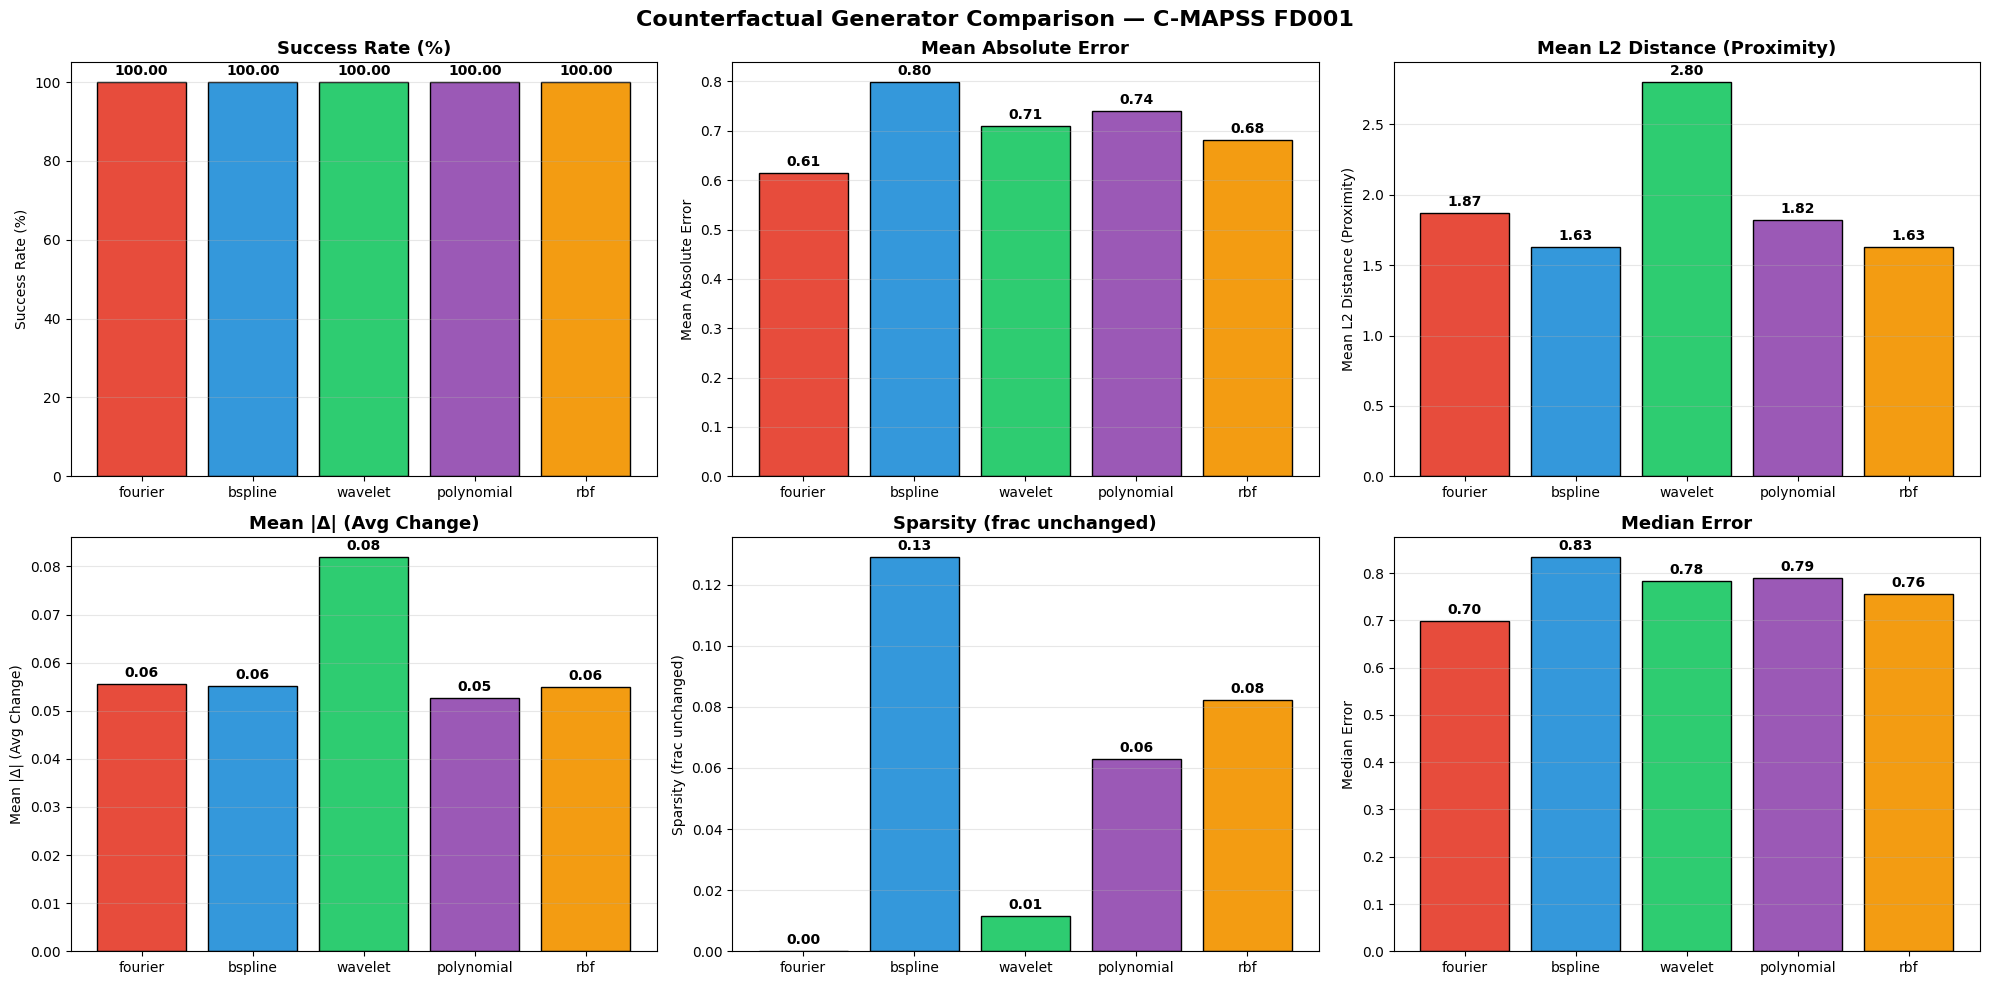

In [11]:
# ── Cell: Bar chart comparison ──

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
metrics = [
    ('Success Rate (%)', 'success', lambda df: df['success'].mean() * 100, 'Greens_d'),
    ('Mean Absolute Error', 'error', lambda df: df['error'].mean(), 'Reds_d'),
    ('Mean L2 Distance (Proximity)', 'l2_distance', lambda df: df['l2_distance'].mean(), 'Blues_d'),
    ('Mean |Δ| (Avg Change)', 'mean_delta', lambda df: df['mean_delta'].mean(), 'Oranges_d'),
    ('Sparsity (frac unchanged)', 'sparsity', lambda df: df['sparsity'].mean(), 'Purples_d'),
    ('Median Error', 'error_med', lambda df: df['error'].median(), 'RdYlGn_r'),
]

gen_names = list(all_results.keys())
colors_map = {'fourier': '#e74c3c', 'bspline': '#3498db', 'wavelet': '#2ecc71', 
              'polynomial': '#9b59b6', 'rbf': '#f39c12'}

for ax, (title, _, compute_fn, cmap) in zip(axes.flat, metrics):
    vals = [compute_fn(all_results[g]) for g in gen_names]
    bars = ax.bar(gen_names, vals, color=[colors_map[g] for g in gen_names], edgecolor='black')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel(title)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01 * max(vals),
                f'{v:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Counterfactual Generator Comparison — C-MAPSS FD001', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/generator_comparison_bars.png', dpi=300, bbox_inches='tight')
plt.show()

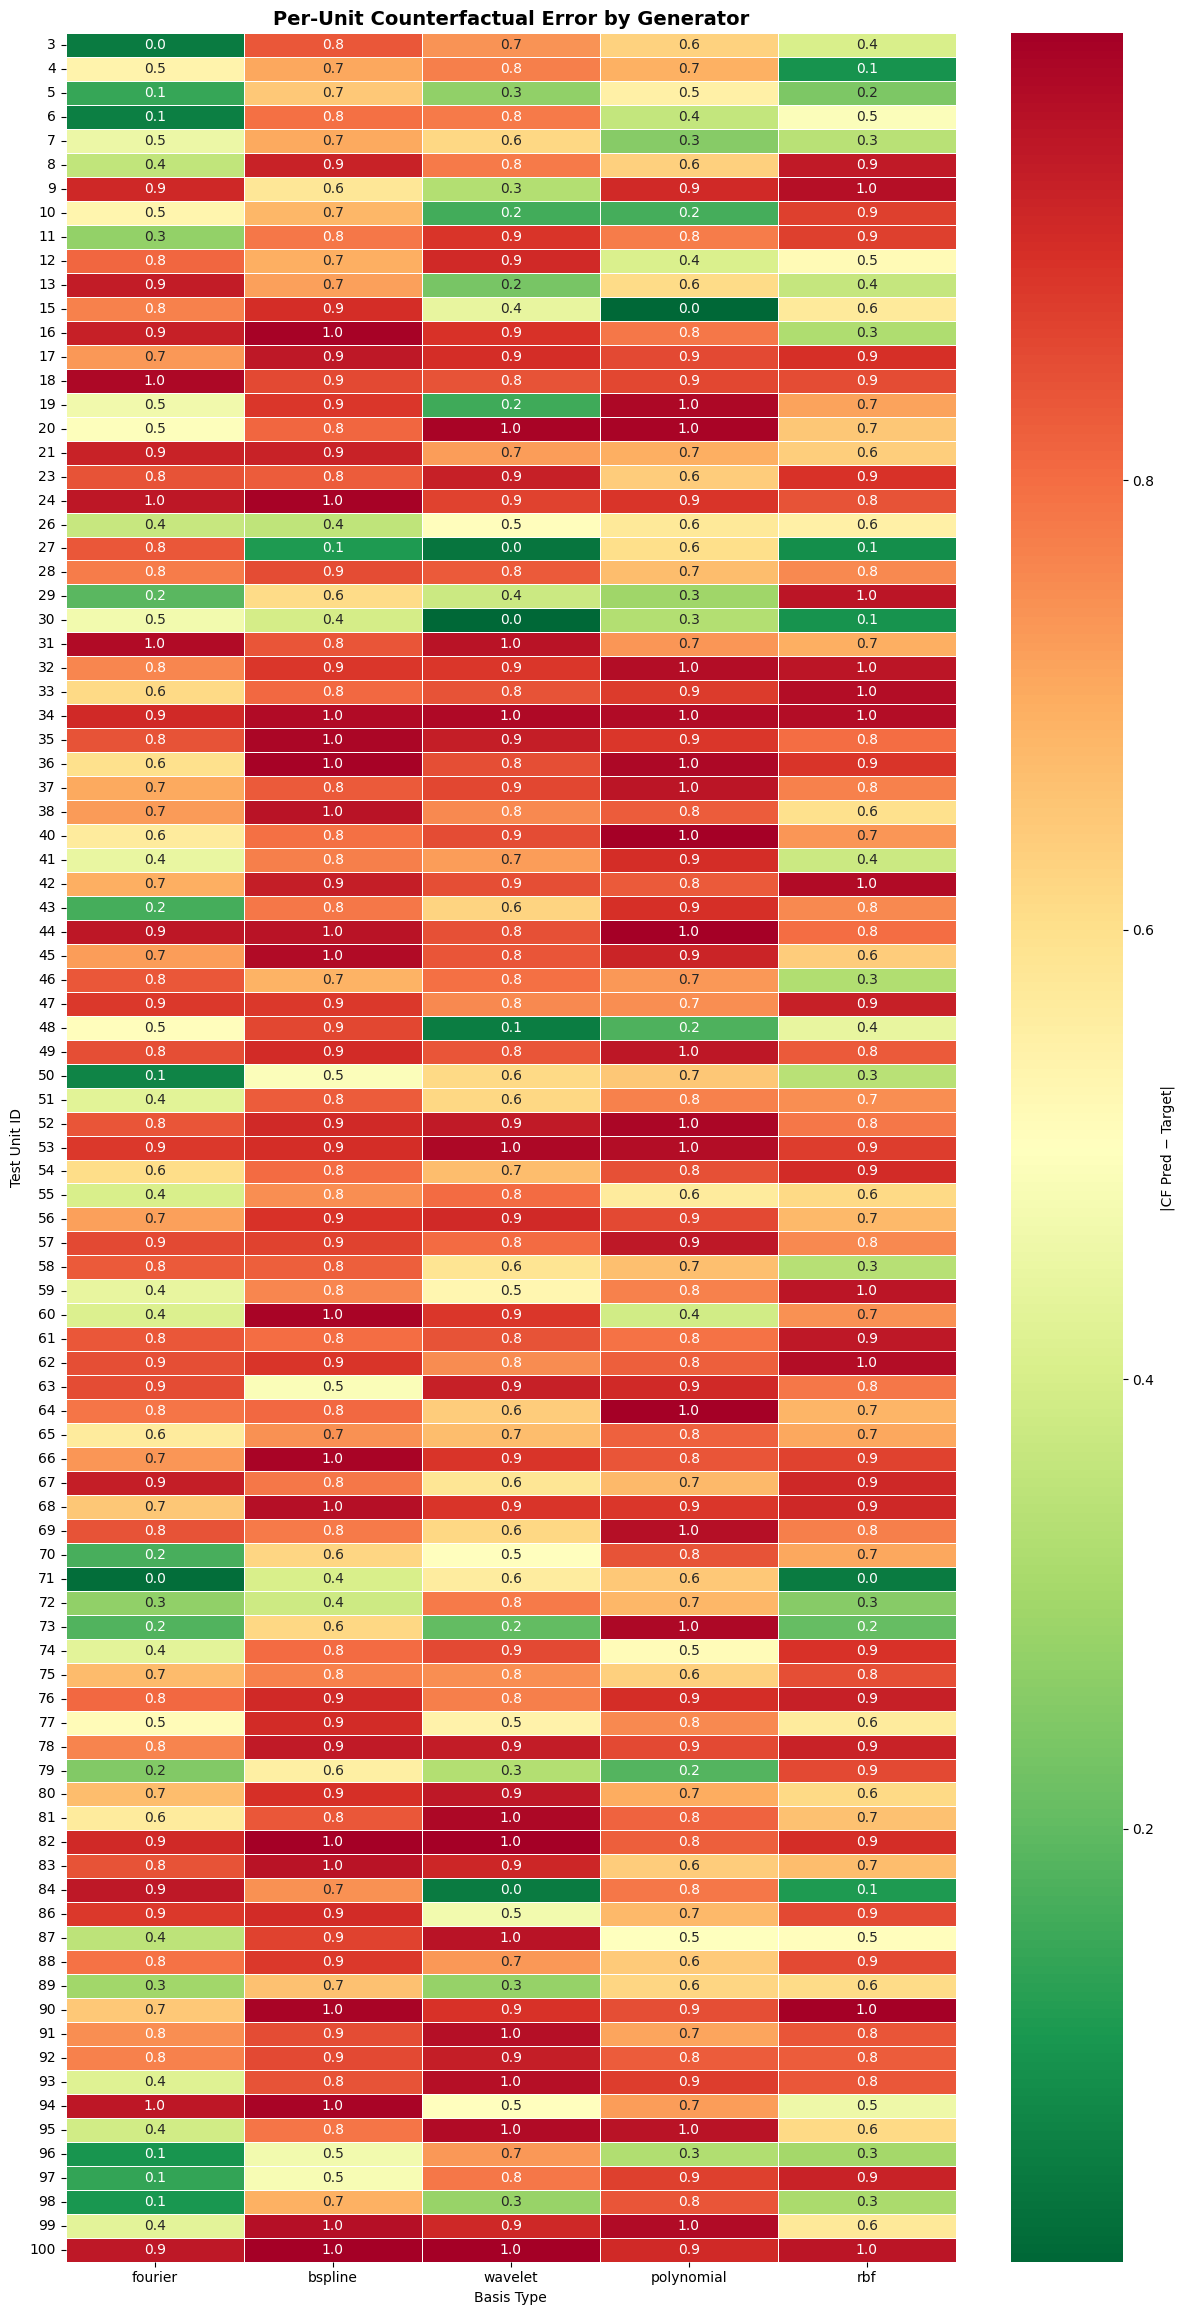

In [12]:
# ── Cell: Per-unit error comparison (heatmap) ──

# Pivot: rows=unit_ids, cols=generators, values=error
error_pivot = pd.DataFrame()
for gen_name, df in all_results.items():
    error_pivot[gen_name] = df.set_index('unit_id')['error']

error_pivot = error_pivot.sort_index()

fig, ax = plt.subplots(figsize=(12, max(8, len(error_pivot) * 0.25)))
sns.heatmap(error_pivot, annot=True, fmt='.1f', cmap='RdYlGn_r', 
            linewidths=0.5, ax=ax, cbar_kws={'label': '|CF Pred − Target|'})
ax.set_title('Per-Unit Counterfactual Error by Generator', fontsize=14, fontweight='bold')
ax.set_xlabel('Basis Type')
ax.set_ylabel('Test Unit ID')
plt.tight_layout()
plt.savefig('../outputs/per_unit_error_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_271520/3512103274.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=error_df, x='Basis', y='Error', ax=axes[0],
/tmp/ipykernel_271520/3512103274.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=l2_df, x='Basis', y='L2 Distance', ax=axes[1],
/tmp/ipykernel_271520/3512103274.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sparse_df, x='Basis', y='Sparsity', ax=axes[2],


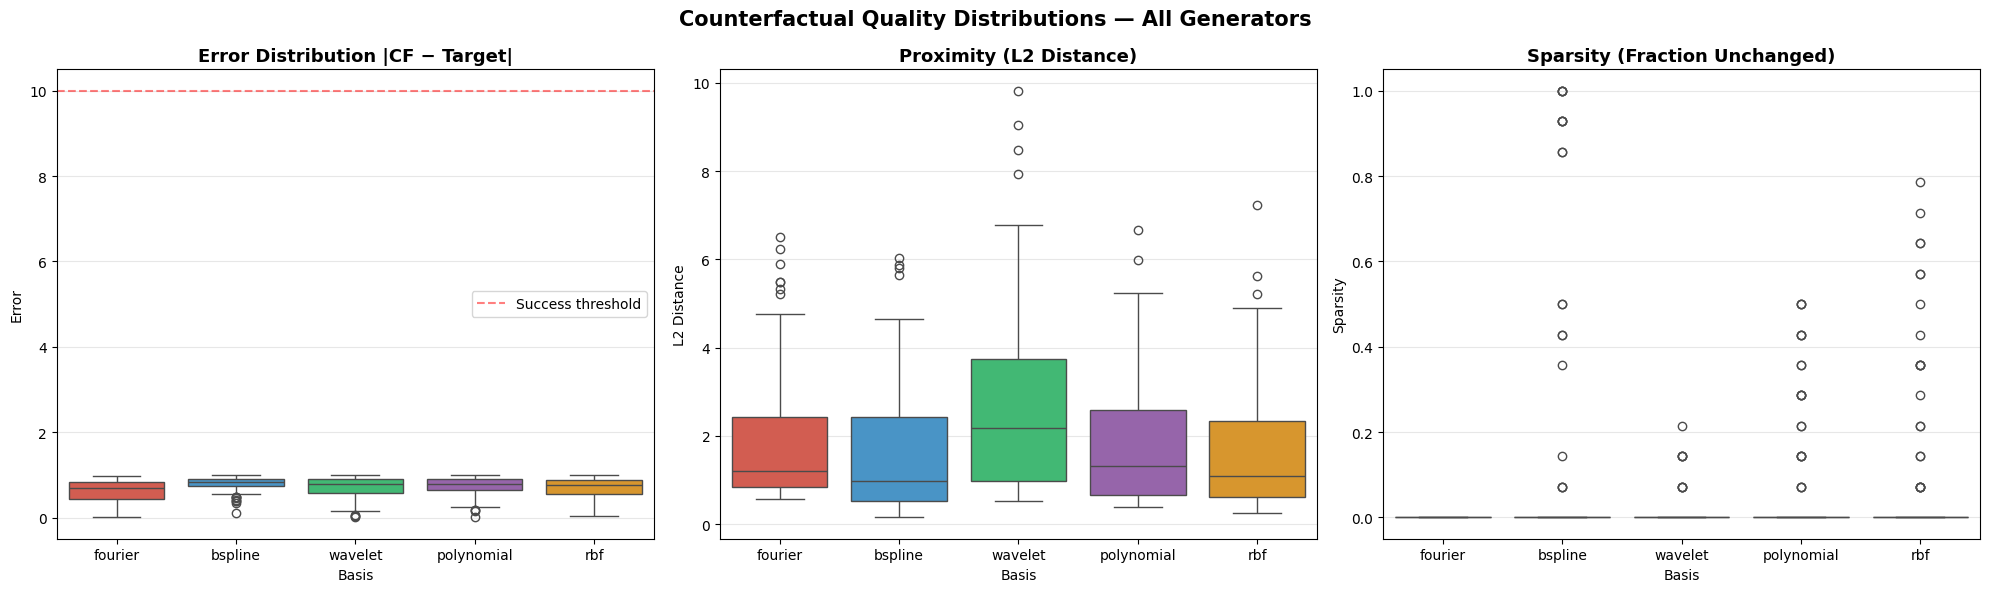

In [14]:
# ── Cell: Box plots of error and proximity distributions ──

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Error distribution
error_data = []
for gen_name, df in all_results.items():
    for _, row in df.iterrows():
        error_data.append({'Basis': gen_name, 'Error': row['error']})
error_df = pd.DataFrame(error_data)

sns.boxplot(data=error_df, x='Basis', y='Error', ax=axes[0], 
            palette=colors_map, order=gen_names)
axes[0].set_title('Error Distribution |CF − Target|', fontsize=13, fontweight='bold')
axes[0].axhline(y=10.0, color='red', linestyle='--', alpha=0.5, label='Success threshold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# 2. L2 distance distribution
l2_data = []
for gen_name, df in all_results.items():
    for _, row in df.iterrows():
        l2_data.append({'Basis': gen_name, 'L2 Distance': row['l2_distance']})
l2_df = pd.DataFrame(l2_data)

sns.boxplot(data=l2_df, x='Basis', y='L2 Distance', ax=axes[1],
            palette=colors_map, order=gen_names)
axes[1].set_title('Proximity (L2 Distance)', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# 3. Sparsity distribution
sparse_data = []
for gen_name, df in all_results.items():
    for _, row in df.iterrows():
        sparse_data.append({'Basis': gen_name, 'Sparsity': row['sparsity']})
sparse_df = pd.DataFrame(sparse_data)

sns.boxplot(data=sparse_df, x='Basis', y='Sparsity', ax=axes[2],
            palette=colors_map, order=gen_names)
axes[2].set_title('Sparsity (Fraction Unchanged)', fontsize=13, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Counterfactual Quality Distributions — All Generators', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/quality_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

Visualizing unit 3


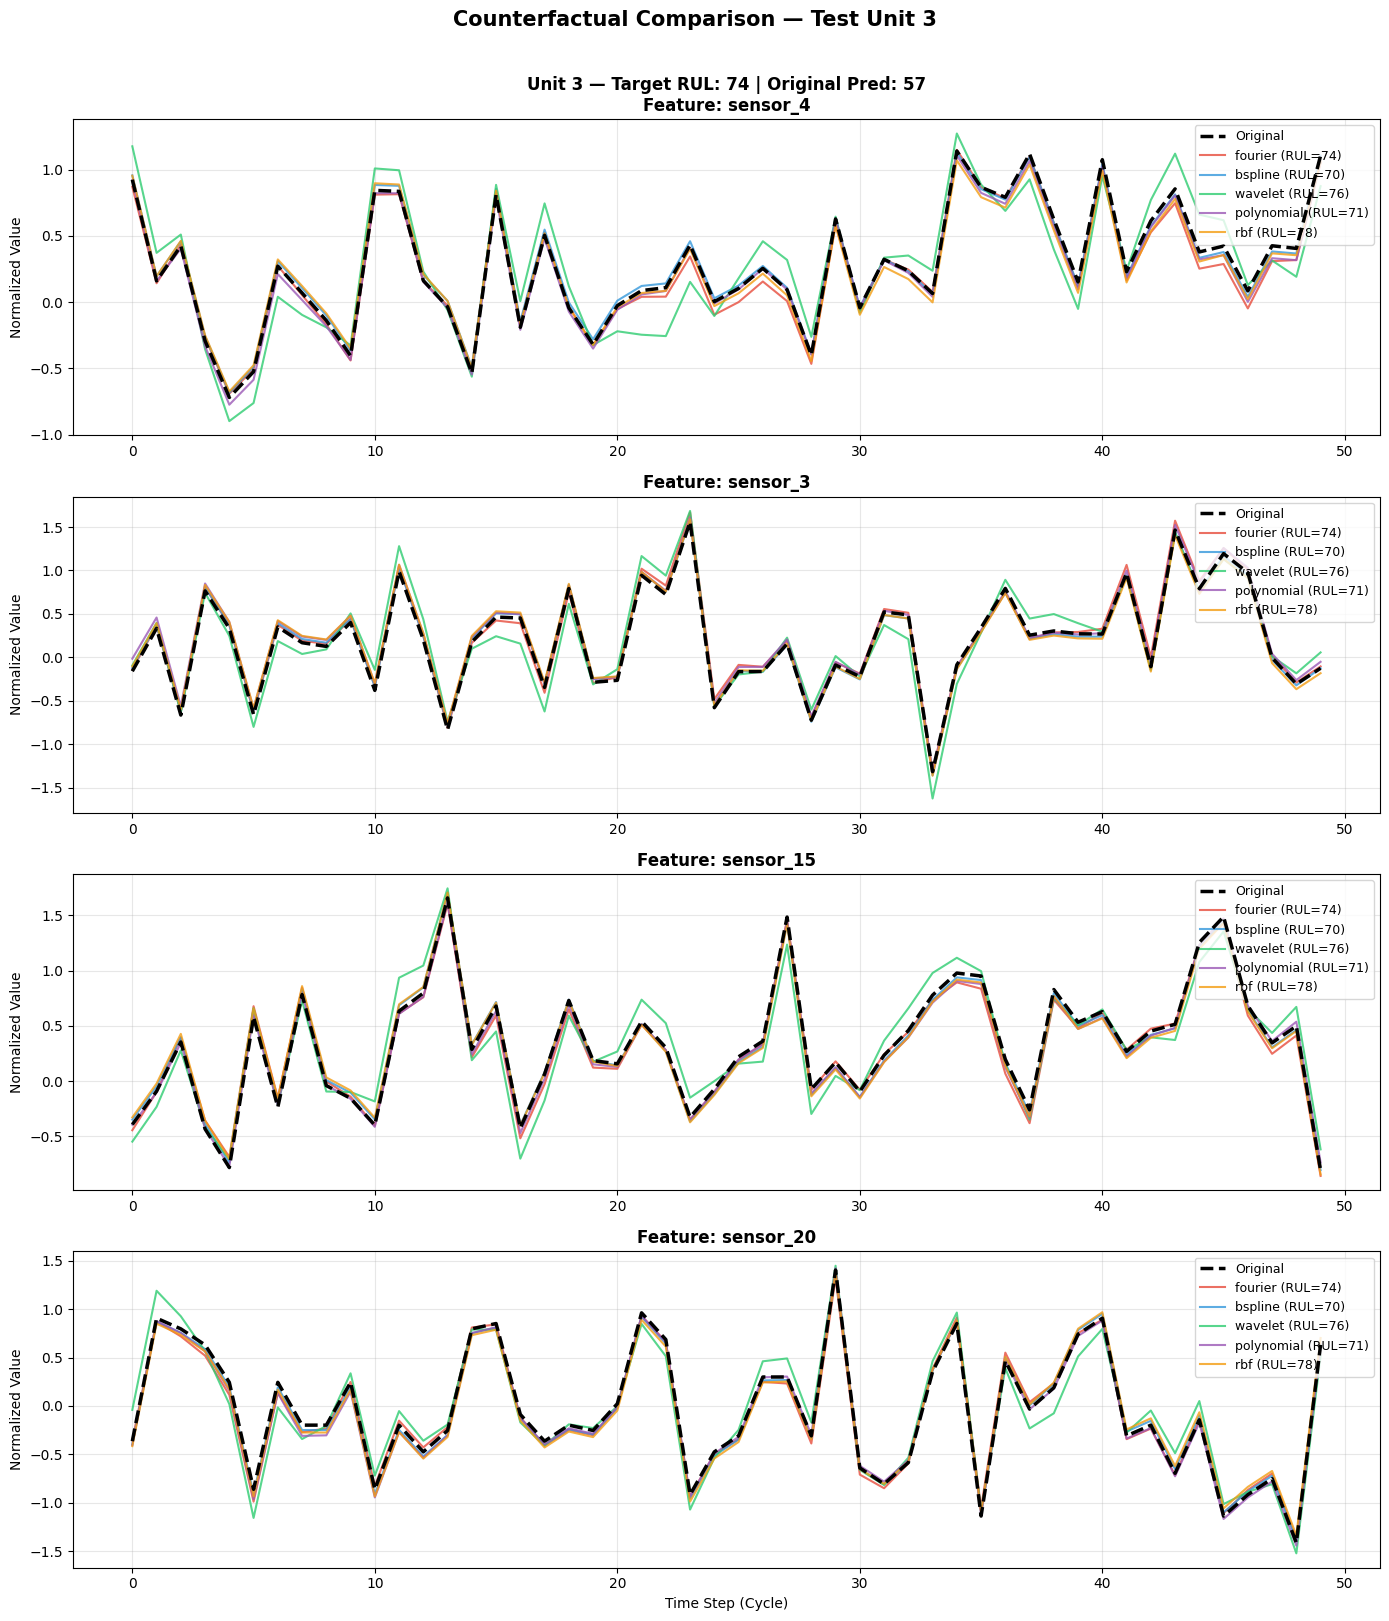

In [ ]:
# ── Cell: Visualize counterfactuals for a sample unit across all generators ──

# Pick a unit that exists in all generators
common_units = set.intersection(*[set(cfs.keys()) for cfs in all_cfs_dict.values()])
sample_unit = sorted(common_units)[0] if common_units else all_test_unit_ids[0] 
print(f"Visualizing unit {sample_unit}")

# Find top 4 most-changed features (averaged across generators)
all_avg_deltas = []
for gen_name, gen_cfs in all_cfs_dict.items():
    if sample_unit in gen_cfs:
        data = gen_cfs[sample_unit]
        all_avg_deltas.append(np.mean(np.abs(data['cf'] - data['original']), axis=0))

overall_delta = np.mean(all_avg_deltas, axis=0)
top_features = np.argsort(overall_delta)[-4:][::-1]

fig, axes = plt.subplots(len(top_features), 1, figsize=(14, 4 * len(top_features)))

for ax_idx, feat_idx in enumerate(top_features):
    ax = axes[ax_idx]
    fname = feature_cols[feat_idx]
    
    # Original
    orig = all_cfs_dict[list(generators.keys())[0]][sample_unit]['original']
    ax.plot(orig[:, feat_idx], 'k--', linewidth=2.5, label='Original', zorder=10)
    
    # Each generator's CF
    for gen_name in generators.keys():
        if sample_unit in all_cfs_dict[gen_name]:
            cf = all_cfs_dict[gen_name][sample_unit]['cf']
            pred = all_cfs_dict[gen_name][sample_unit]['cf_pred']
            ax.plot(cf[:, feat_idx], color=colors_map[gen_name], alpha=0.8, linewidth=1.5,
                    label=f'{gen_name} (RUL={pred:.0f})')
    
    ax.set_title(f'Feature: {fname}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Normalized Value')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=9)

target_info = all_cfs_dict[list(generators.keys())[0]][sample_unit]
axes[0].set_title(
    f'Unit {sample_unit} — Target RUL: {target_info["target_rul"]:.0f} | '
    f'Original Pred: {target_info["current_pred"]:.0f}\n'
    f'Feature: {feature_cols[top_features[0]]}',
    fontsize=12, fontweight='bold'
)
axes[-1].set_xlabel('Time Step (Cycle)')

plt.suptitle(f'Counterfactual Comparison — Test Unit {sample_unit}', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'../outputs/cf_comparison_unit_{sample_unit}.png', dpi=300, bbox_inches='tight')
plt.show()

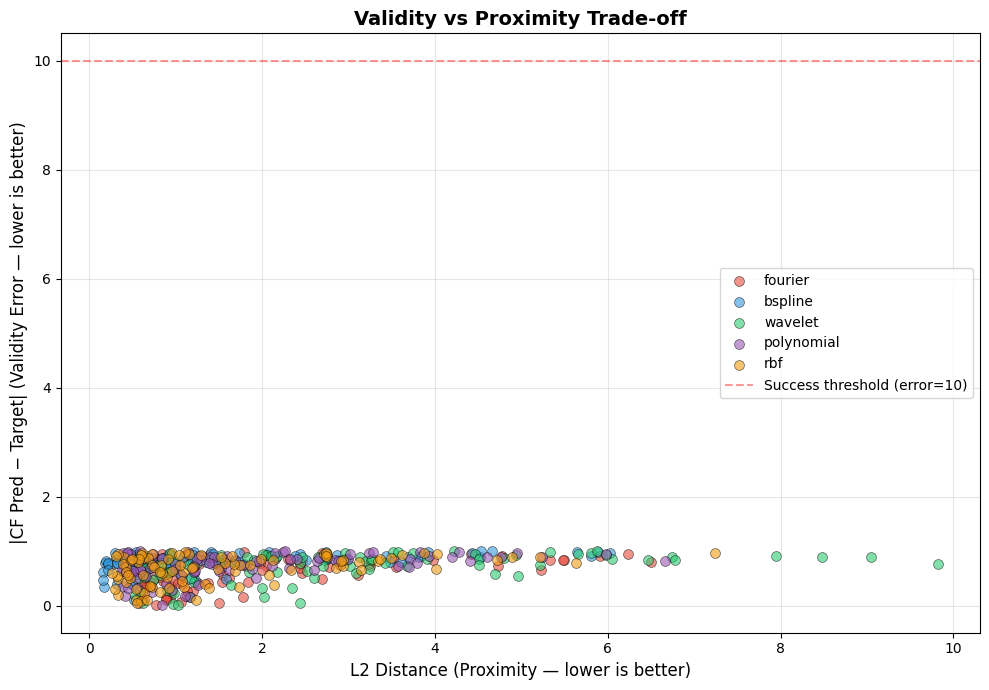

In [16]:
# ── Cell: Error vs Proximity trade-off scatter ──

fig, ax = plt.subplots(figsize=(10, 7))

for gen_name, df in all_results.items():
    ax.scatter(df['l2_distance'], df['error'], 
               label=gen_name, color=colors_map[gen_name], 
               alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

ax.axhline(y=10.0, color='red', linestyle='--', alpha=0.4, label='Success threshold (error=10)')
ax.set_xlabel('L2 Distance (Proximity — lower is better)', fontsize=12)
ax.set_ylabel('|CF Pred − Target| (Validity Error — lower is better)', fontsize=12)
ax.set_title('Validity vs Proximity Trade-off', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/error_vs_proximity_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_271520/3702588985.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=smooth_df, x='Basis', y='cf_smoothness', ax=axes[0],
/tmp/ipykernel_271520/3702588985.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=smooth_df, x='Basis', y='smoothness_ratio', ax=axes[1],


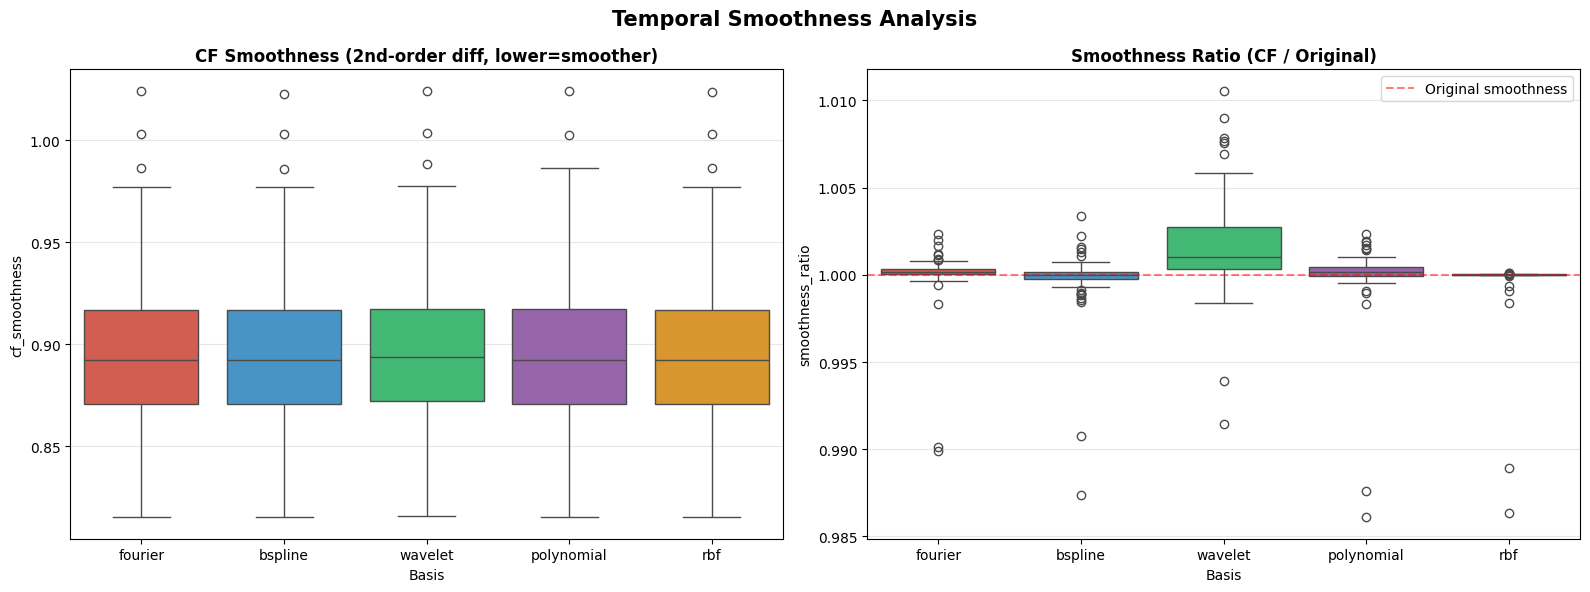

In [17]:
# ── Cell: Smoothness analysis — measure temporal jitter of CFs ──

def compute_smoothness(ts):
    """Compute mean absolute second-order difference (lower = smoother)"""
    diffs = np.diff(ts, n=2, axis=0)  # (T-2, D)
    return np.mean(np.abs(diffs))

smoothness_rows = []
for gen_name, gen_cfs in all_cfs_dict.items():
    for uid, data in gen_cfs.items():
        orig_smooth = compute_smoothness(data['original'])
        cf_smooth = compute_smoothness(data['cf'])
        smoothness_rows.append({
            'Basis': gen_name,
            'unit_id': uid,
            'original_smoothness': orig_smooth,
            'cf_smoothness': cf_smooth,
            'smoothness_ratio': cf_smooth / (orig_smooth + 1e-8),
        })

smooth_df = pd.DataFrame(smoothness_rows)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Smoothness of CFs
sns.boxplot(data=smooth_df, x='Basis', y='cf_smoothness', ax=axes[0],
            palette=colors_map, order=gen_names)
axes[0].set_title('CF Smoothness (2nd-order diff, lower=smoother)', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Ratio: CF smoothness / original smoothness (closer to 1 = more realistic)
sns.boxplot(data=smooth_df, x='Basis', y='smoothness_ratio', ax=axes[1],
            palette=colors_map, order=gen_names)
axes[1].axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Original smoothness')
axes[1].set_title('Smoothness Ratio (CF / Original)', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Temporal Smoothness Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/smoothness_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


  ERROR ANALYSIS: FOURIER
  Total units: 93
  Successes: 93 (100.0%)
  Failures:  0 (0.0%)

  ERROR ANALYSIS: BSPLINE
  Total units: 93
  Successes: 93 (100.0%)
  Failures:  0 (0.0%)

  ERROR ANALYSIS: WAVELET
  Total units: 93
  Successes: 93 (100.0%)
  Failures:  0 (0.0%)

  ERROR ANALYSIS: POLYNOMIAL
  Total units: 93
  Successes: 93 (100.0%)
  Failures:  0 (0.0%)

  ERROR ANALYSIS: RBF
  Total units: 93
  Successes: 93 (100.0%)
  Failures:  0 (0.0%)


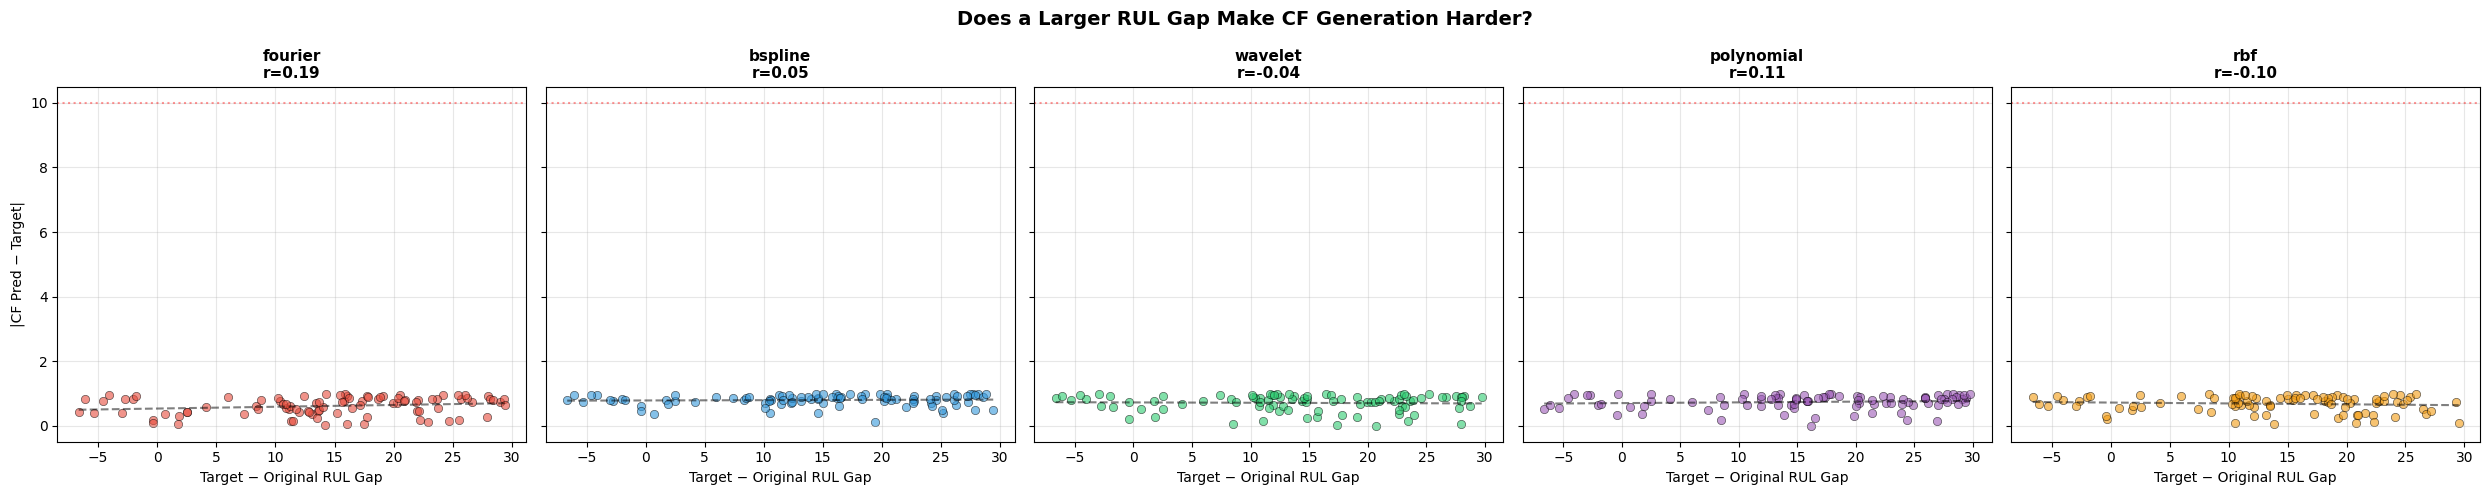

In [18]:
# ── Cell: Error analysis — identify failure patterns ──

for gen_name, df in all_results.items():
    print(f"\n{'='*70}")
    print(f"  ERROR ANALYSIS: {gen_name.upper()}")
    print(f"{'='*70}")
    
    failures = df[~df['success']].copy()
    successes = df[df['success']].copy()
    
    print(f"  Total units: {len(df)}")
    print(f"  Successes: {len(successes)} ({len(successes)/len(df)*100:.1f}%)")
    print(f"  Failures:  {len(failures)} ({len(failures)/len(df)*100:.1f}%)")
    
    if len(failures) > 0:
        print(f"\n  Failed units: {failures['unit_id'].tolist()}")
        print(f"  Failure error — mean: {failures['error'].mean():.2f}, max: {failures['error'].max():.2f}")
        print(f"  Failure original_pred — mean: {failures['original_pred'].mean():.1f}")
        print(f"  Success original_pred — mean: {successes['original_pred'].mean():.1f}" if len(successes) > 0 else "")
        
        # Is it harder when original pred is already high?
        print(f"\n  Failure target_rul — mean: {failures['target_rul'].mean():.1f}")
        print(f"  Failure target−original gap — mean: {(failures['target_rul'] - failures['original_pred']).mean():.1f}")
        if len(successes) > 0:
            print(f"  Success target−original gap — mean: {(successes['target_rul'] - successes['original_pred']).mean():.1f}")

# ── Correlation: does a larger RUL gap lead to higher errors? ──
fig, axes = plt.subplots(1, len(generators), figsize=(5 * len(generators), 5), sharey=True)

for ax, (gen_name, df) in zip(axes, all_results.items()):
    df = df.copy()
    df['rul_gap'] = df['target_rul'] - df['original_pred']
    ax.scatter(df['rul_gap'], df['error'], color=colors_map[gen_name], 
               alpha=0.6, edgecolors='black', linewidth=0.5)
    
    # Trend line
    z = np.polyfit(df['rul_gap'], df['error'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df['rul_gap'].min(), df['rul_gap'].max(), 100)
    ax.plot(x_line, p(x_line), '--', color='black', alpha=0.5)
    
    corr = df['rul_gap'].corr(df['error'])
    ax.set_title(f'{gen_name}\nr={corr:.2f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Target − Original RUL Gap')
    ax.axhline(y=10, color='red', linestyle=':', alpha=0.4)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('|CF Pred − Target|')
plt.suptitle('Does a Larger RUL Gap Make CF Generation Harder?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/error_vs_rul_gap.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# ── Cell: Save all results ──

output_dir = Path('../outputs/counterfactuals_all_generators')
output_dir.mkdir(parents=True, exist_ok=True)

# Save summary
summary_df.to_csv(output_dir / 'summary_comparison.csv')

# Save per-generator results
for gen_name, df in all_results.items():
    df.to_csv(output_dir / f'results_{gen_name}.csv', index=False)

# Save counterfactual arrays
for gen_name, gen_cfs in all_cfs_dict.items():
    gen_dir = output_dir / gen_name
    gen_dir.mkdir(exist_ok=True)
    for uid, data in gen_cfs.items():
        np.savez(gen_dir / f'unit_{uid}.npz',
                 original=data['original'],
                 cf=data['cf'],
                 target_rul=data['target_rul'],
                 current_pred=data['current_pred'],
                 cf_pred=data['cf_pred'],
                 true_rul=data['true_rul'])

# Save smoothness data
smooth_df.to_csv(output_dir / 'smoothness_analysis.csv', index=False)

print(f"✅ All results saved to {output_dir}")
print(f"  - summary_comparison.csv")
print(f"  - results_<basis>.csv (×{len(generators)})")
print(f"  - <basis>/unit_<id>.npz (counterfactual arrays)")
print(f"  - smoothness_analysis.csv")

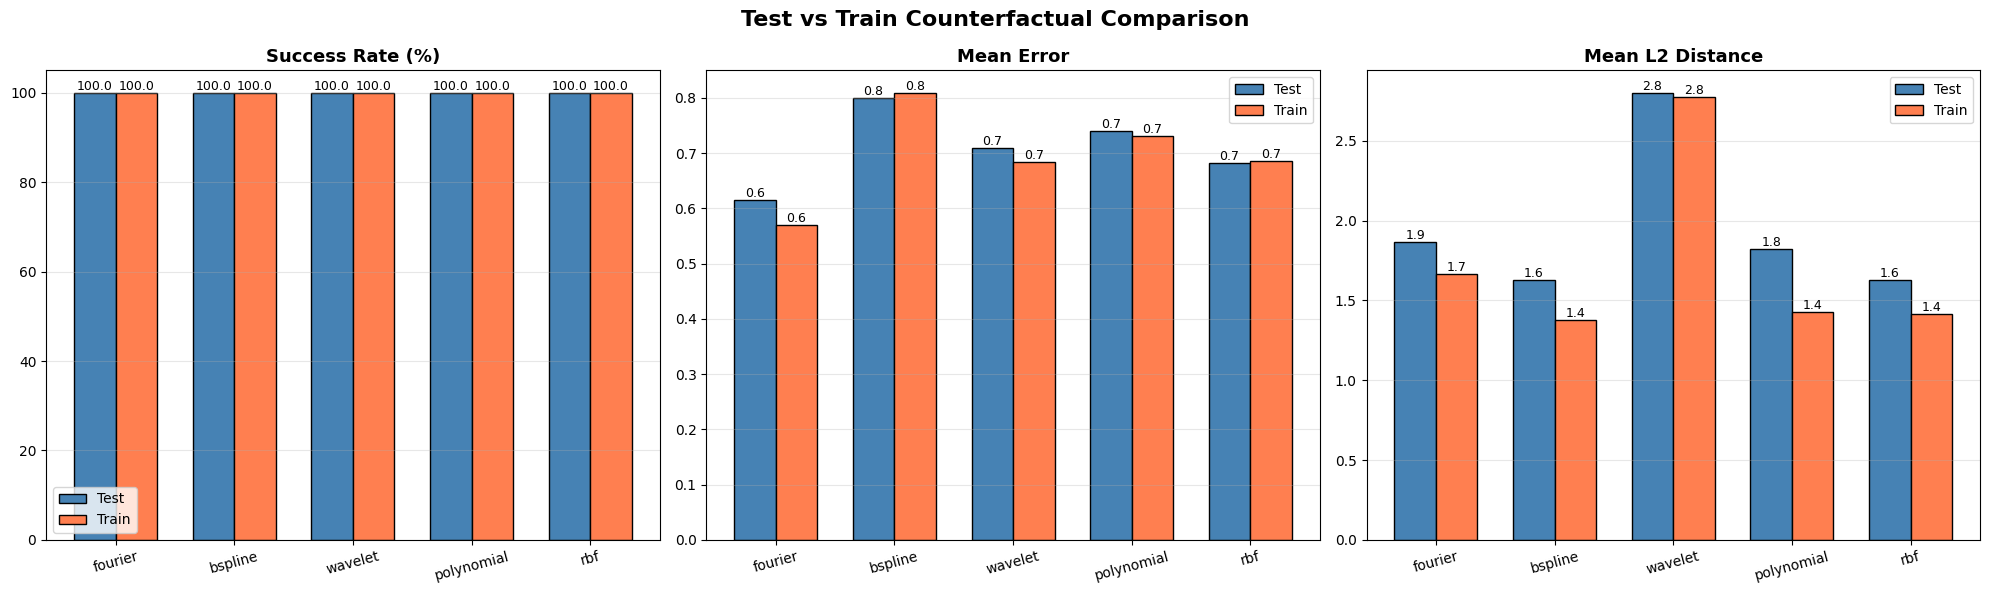

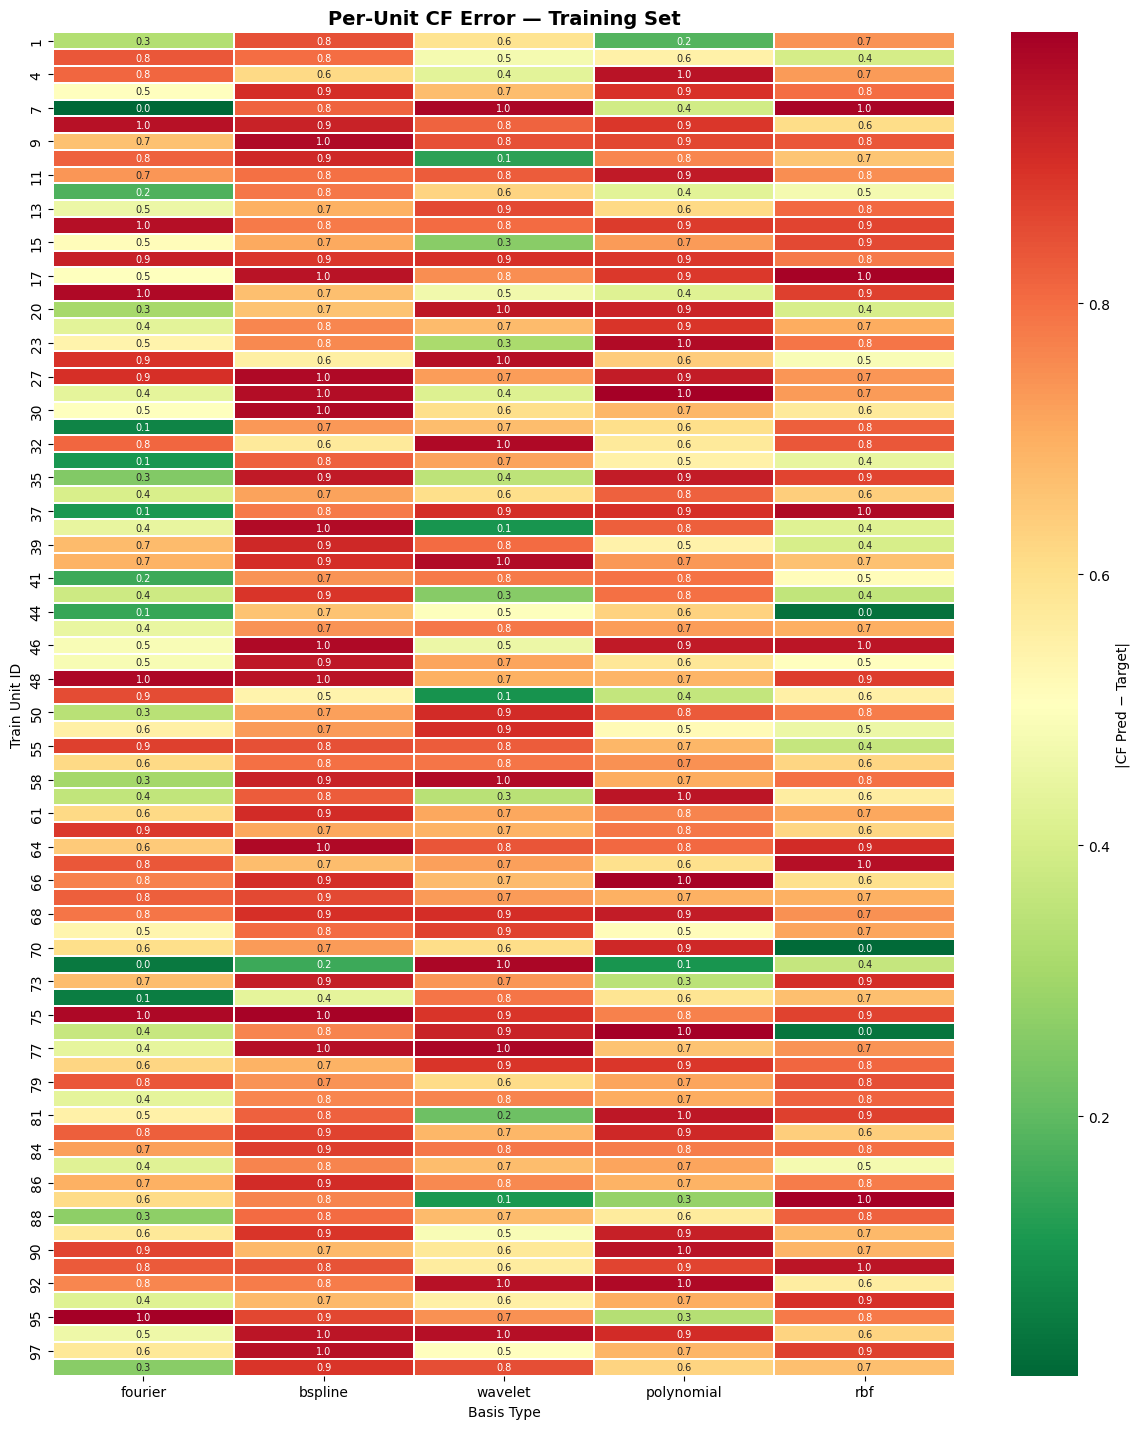

/tmp/ipykernel_271520/3707937133.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pd.DataFrame(train_error_data), x='Basis', y='Error', ax=axes[0],
/tmp/ipykernel_271520/3707937133.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pd.DataFrame(train_l2_data), x='Basis', y='L2 Distance', ax=axes[1],
/tmp/ipykernel_271520/3707937133.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pd.DataFrame(train_sparse_data), x='Basis', y='Sparsity', ax=axes[2],


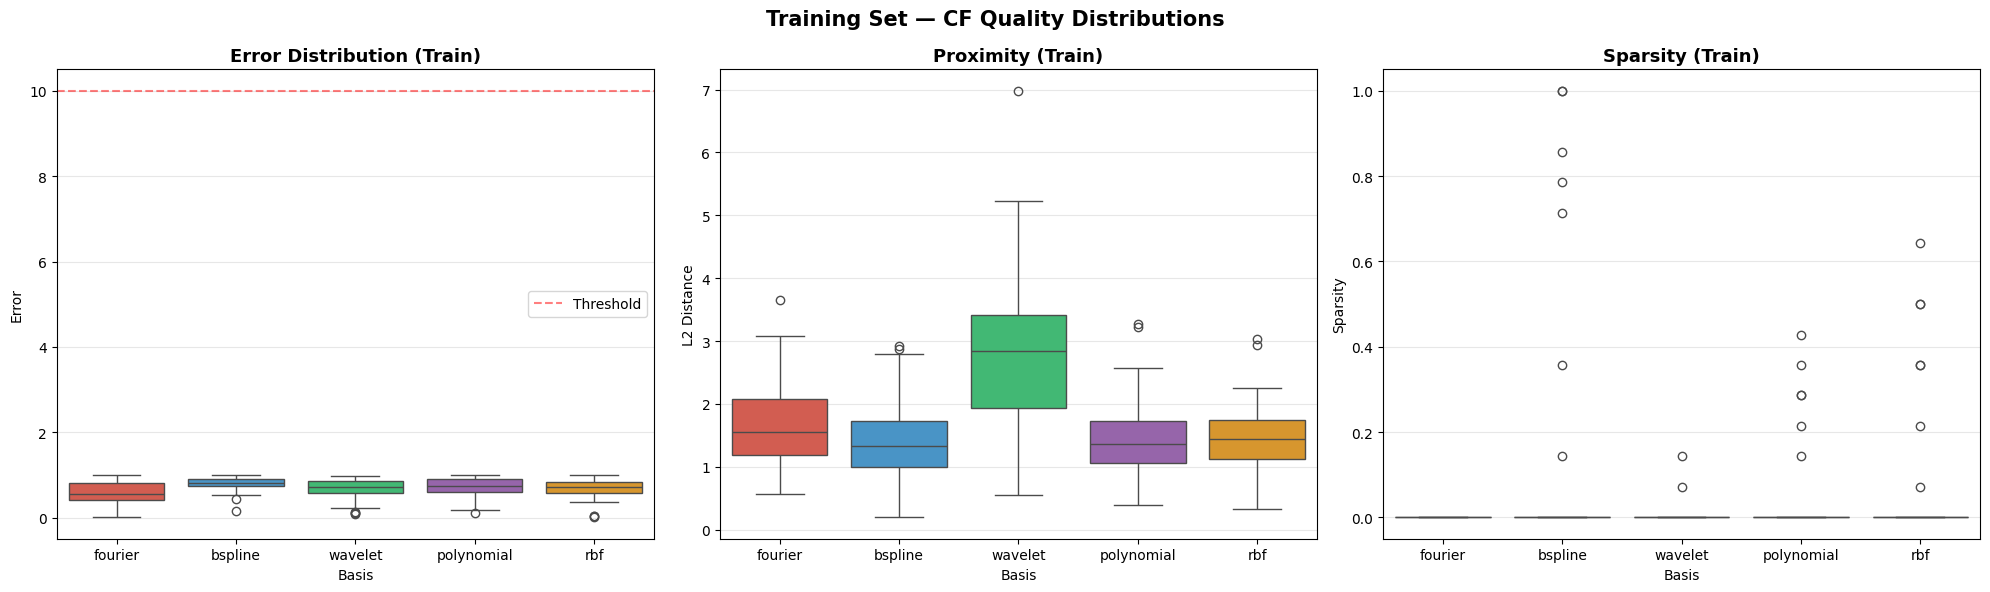

/tmp/ipykernel_271520/3707937133.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_smooth_df, x='Basis', y='cf_smoothness', ax=axes[0],
/tmp/ipykernel_271520/3707937133.py:112: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_smooth_df, x='Basis', y='smoothness_ratio', ax=axes[1],


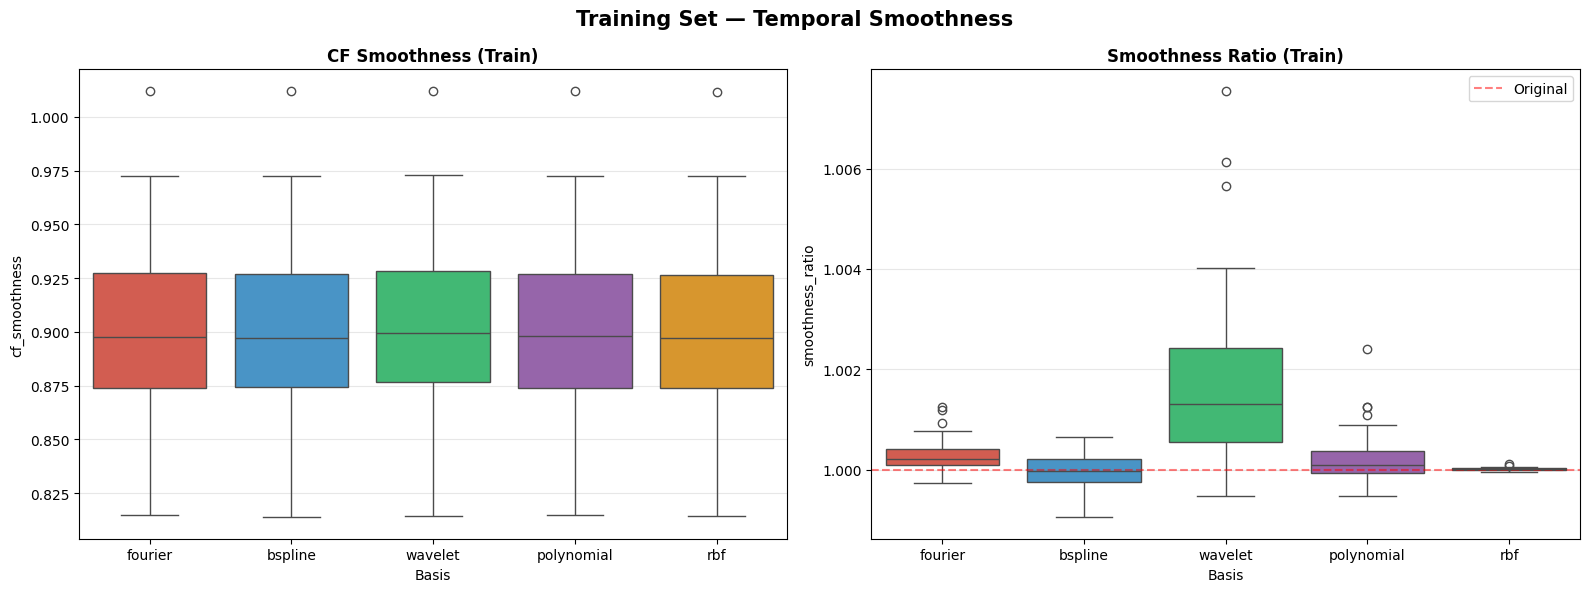

In [25]:
# ── Cell: Training set plots — bar chart, box plots, smoothness ──

# ── 1. Bar chart: Test vs Train side-by-side ──
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
metric_fns = [
    ('Success Rate (%)', lambda df: df['success'].mean() * 100),
    ('Mean Error', lambda df: df['error'].mean()),
    ('Mean L2 Distance', lambda df: df['l2_distance'].mean()),
]
gen_names = list(generators.keys())
x = np.arange(len(gen_names))
width = 0.35

for ax, (title, fn) in zip(axes, metric_fns):
    test_vals = [fn(all_results[g]) for g in gen_names]
    train_vals = [fn(all_train_results[g]) for g in gen_names]
    
    bars1 = ax.bar(x - width/2, test_vals, width, label='Test', color='steelblue', edgecolor='black')
    bars2 = ax.bar(x + width/2, train_vals, width, label='Train', color='coral', edgecolor='black')
    
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(gen_names, rotation=15)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    for bar, v in zip(bars1, test_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{v:.1f}',
                ha='center', va='bottom', fontsize=9)
    for bar, v in zip(bars2, train_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{v:.1f}',
                ha='center', va='bottom', fontsize=9)

plt.suptitle('Test vs Train Counterfactual Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/test_vs_train_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ── 2. Training error heatmap ──
train_error_pivot = pd.DataFrame()
for gen_name, df in all_train_results.items():
    train_error_pivot[gen_name] = df.set_index('unit_id')['error']
train_error_pivot = train_error_pivot.sort_index()

fig, ax = plt.subplots(figsize=(12, max(8, len(train_error_pivot) * 0.18)))
sns.heatmap(train_error_pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.3, ax=ax, cbar_kws={'label': '|CF Pred − Target|'},
            annot_kws={'fontsize': 7})
ax.set_title('Per-Unit CF Error — Training Set', fontsize=14, fontweight='bold')
ax.set_xlabel('Basis Type')
ax.set_ylabel('Train Unit ID')
plt.tight_layout()
plt.savefig('../outputs/train_per_unit_error_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# ── 3. Training box plots ──
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

train_error_data = []
train_l2_data = []
train_sparse_data = []
for gen_name, df in all_train_results.items():
    for _, row in df.iterrows():
        train_error_data.append({'Basis': gen_name, 'Error': row['error']})
        train_l2_data.append({'Basis': gen_name, 'L2 Distance': row['l2_distance']})
        train_sparse_data.append({'Basis': gen_name, 'Sparsity': row['sparsity']})

sns.boxplot(data=pd.DataFrame(train_error_data), x='Basis', y='Error', ax=axes[0],
            palette=colors_map, order=gen_names)
axes[0].set_title('Error Distribution (Train)', fontsize=13, fontweight='bold')
axes[0].axhline(y=10.0, color='red', linestyle='--', alpha=0.5, label='Threshold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

sns.boxplot(data=pd.DataFrame(train_l2_data), x='Basis', y='L2 Distance', ax=axes[1],
            palette=colors_map, order=gen_names)
axes[1].set_title('Proximity (Train)', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

sns.boxplot(data=pd.DataFrame(train_sparse_data), x='Basis', y='Sparsity', ax=axes[2],
            palette=colors_map, order=gen_names)
axes[2].set_title('Sparsity (Train)', fontsize=13, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Training Set — CF Quality Distributions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/train_quality_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

# ── 4. Training smoothness ──
train_smooth_rows = []
for gen_name, gen_cfs in all_train_cfs_dict.items():
    for uid, data in gen_cfs.items():
        orig_smooth = compute_smoothness(data['original'])
        cf_smooth = compute_smoothness(data['cf'])
        train_smooth_rows.append({
            'Basis': gen_name,
            'unit_id': uid,
            'original_smoothness': orig_smooth,
            'cf_smoothness': cf_smooth,
            'smoothness_ratio': cf_smooth / (orig_smooth + 1e-8),
        })

train_smooth_df = pd.DataFrame(train_smooth_rows)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=train_smooth_df, x='Basis', y='cf_smoothness', ax=axes[0],
            palette=colors_map, order=gen_names)
axes[0].set_title('CF Smoothness (Train)', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

sns.boxplot(data=train_smooth_df, x='Basis', y='smoothness_ratio', ax=axes[1],
            palette=colors_map, order=gen_names)
axes[1].axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Original')
axes[1].set_title('Smoothness Ratio (Train)', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Training Set — Temporal Smoothness', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/train_smoothness_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


  ERROR ANALYSIS (TRAIN): FOURIER
  Total units: 80
  Successes: 80 (100.0%)
  Failures:  0 (0.0%)

  ERROR ANALYSIS (TRAIN): BSPLINE
  Total units: 80
  Successes: 80 (100.0%)
  Failures:  0 (0.0%)

  ERROR ANALYSIS (TRAIN): WAVELET
  Total units: 80
  Successes: 80 (100.0%)
  Failures:  0 (0.0%)

  ERROR ANALYSIS (TRAIN): POLYNOMIAL
  Total units: 80
  Successes: 80 (100.0%)
  Failures:  0 (0.0%)

  ERROR ANALYSIS (TRAIN): RBF
  Total units: 80
  Successes: 80 (100.0%)
  Failures:  0 (0.0%)


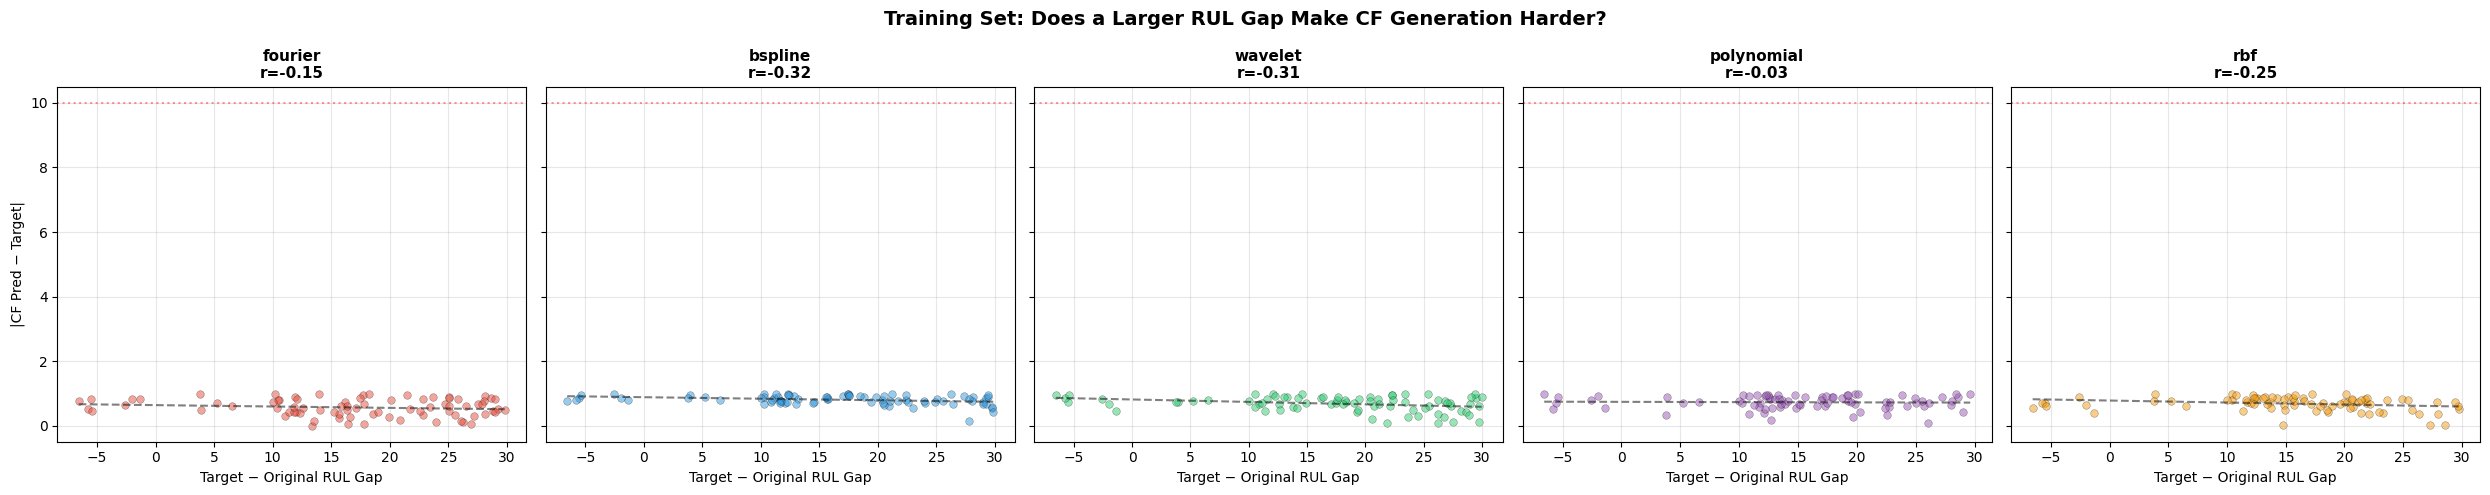

In [26]:
# ── Cell: Training set error analysis + RUL gap correlation ──

for gen_name, df in all_train_results.items():
    print(f"\n{'='*70}")
    print(f"  ERROR ANALYSIS (TRAIN): {gen_name.upper()}")
    print(f"{'='*70}")
    
    failures = df[~df['success']].copy()
    successes = df[df['success']].copy()
    
    print(f"  Total units: {len(df)}")
    print(f"  Successes: {len(successes)} ({len(successes)/len(df)*100:.1f}%)")
    print(f"  Failures:  {len(failures)} ({len(failures)/len(df)*100:.1f}%)")
    
    if len(failures) > 0:
        print(f"\n  Failed units: {failures['unit_id'].tolist()[:20]}{'...' if len(failures) > 20 else ''}")
        print(f"  Failure error — mean: {failures['error'].mean():.2f}, max: {failures['error'].max():.2f}")
        print(f"  Failure original_pred — mean: {failures['original_pred'].mean():.1f}")
        if len(successes) > 0:
            print(f"  Success original_pred — mean: {successes['original_pred'].mean():.1f}")
        print(f"  Failure target−original gap — mean: {(failures['target_rul'] - failures['original_pred']).mean():.1f}")
        if len(successes) > 0:
            print(f"  Success target−original gap — mean: {(successes['target_rul'] - successes['original_pred']).mean():.1f}")

# ── RUL gap vs error scatter ──
fig, axes = plt.subplots(1, len(generators), figsize=(5 * len(generators), 5), sharey=True)

for ax, (gen_name, df) in zip(axes, all_train_results.items()):
    df = df.copy()
    df['rul_gap'] = df['target_rul'] - df['original_pred']
    ax.scatter(df['rul_gap'], df['error'], color=colors_map[gen_name],
               alpha=0.5, s=30, edgecolors='black', linewidth=0.3)
    
    z = np.polyfit(df['rul_gap'], df['error'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df['rul_gap'].min(), df['rul_gap'].max(), 100)
    ax.plot(x_line, p(x_line), '--', color='black', alpha=0.5)
    
    corr = df['rul_gap'].corr(df['error'])
    ax.set_title(f'{gen_name}\nr={corr:.2f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Target − Original RUL Gap')
    ax.axhline(y=10, color='red', linestyle=':', alpha=0.4)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('|CF Pred − Target|')
plt.suptitle('Training Set: Does a Larger RUL Gap Make CF Generation Harder?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/train_error_vs_rul_gap.png', dpi=300, bbox_inches='tight')
plt.show()

Visualizing training unit 1


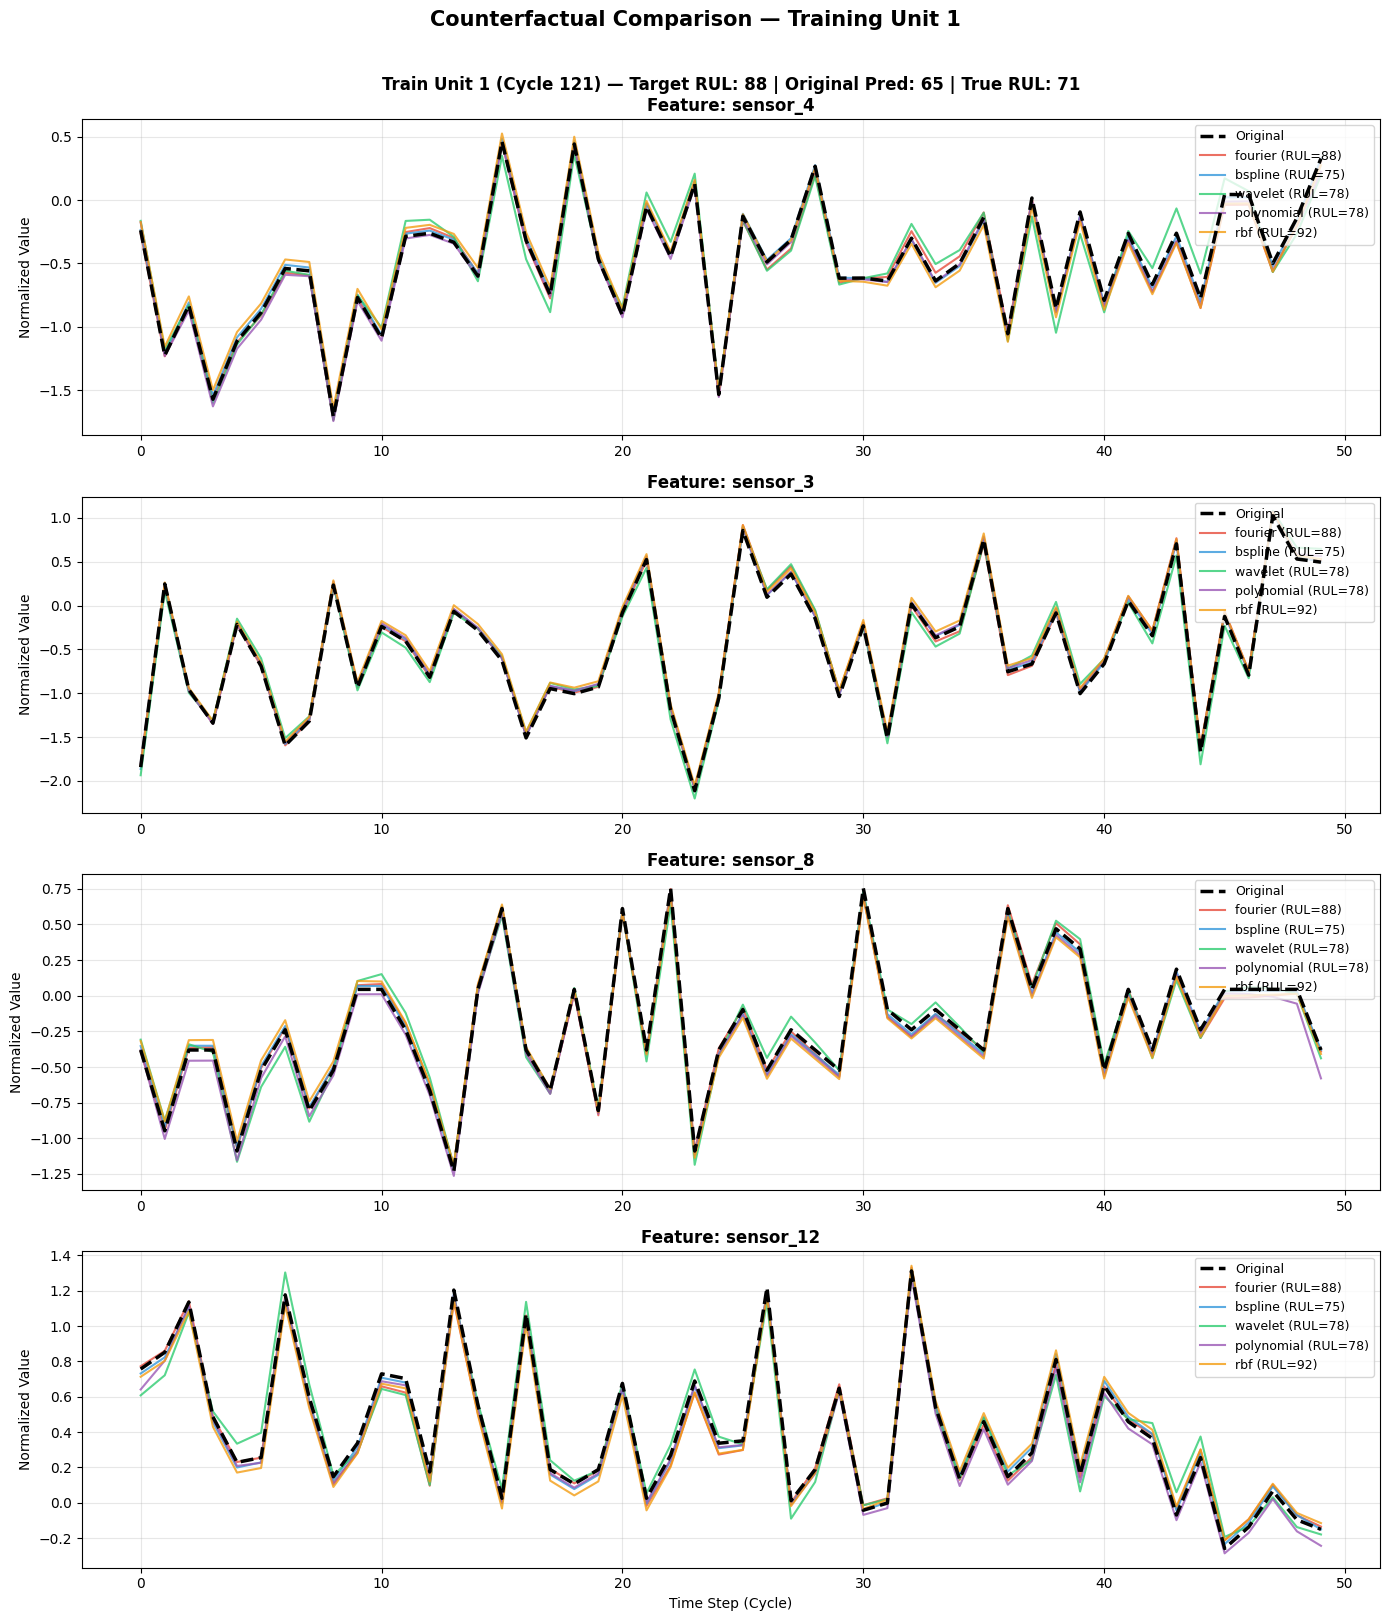

In [27]:
# ── Cell: Visualize counterfactuals for a sample TRAINING unit across all generators ──

# Pick a training unit that exists in all generators
common_train_units = set.intersection(*[set(gen_cfs_dict.keys()) for gen_cfs_dict in all_train_cfs_dict.values()])
sample_train_unit = sorted(common_train_units)[0] if common_train_units else all_train_unit_ids[0]
print(f"Visualizing training unit {sample_train_unit}")

# Find top 4 most-changed features (averaged across generators)
all_avg_deltas_train = []
for gen_name, gen_cfs in all_train_cfs_dict.items():
    if sample_train_unit in gen_cfs:
        data = gen_cfs[sample_train_unit]
        all_avg_deltas_train.append(np.mean(np.abs(data['cf'] - data['original']), axis=0))

overall_delta_train = np.mean(all_avg_deltas_train, axis=0)
top_features_train = np.argsort(overall_delta_train)[-4:][::-1]

fig, axes = plt.subplots(len(top_features_train), 1, figsize=(14, 4 * len(top_features_train)))
if len(top_features_train) == 1:
    axes = [axes]

for ax_idx, feat_idx in enumerate(top_features_train):
    ax = axes[ax_idx]
    fname = feature_cols[feat_idx]
    
    # Original
    first_gen = list(generators.keys())[0]
    orig = all_train_cfs_dict[first_gen][sample_train_unit]['original']
    ax.plot(orig[:, feat_idx], 'k--', linewidth=2.5, label='Original', zorder=10)
    
    # Each generator's CF
    for gen_name in generators.keys():
        if sample_train_unit in all_train_cfs_dict[gen_name]:
            cf = all_train_cfs_dict[gen_name][sample_train_unit]['cf']
            pred = all_train_cfs_dict[gen_name][sample_train_unit]['cf_pred']
            ax.plot(cf[:, feat_idx], color=colors_map[gen_name], alpha=0.8, linewidth=1.5,
                    label=f'{gen_name} (RUL={pred:.0f})')
    
    ax.set_title(f'Feature: {fname}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Normalized Value')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=9)

target_info_train = all_train_cfs_dict[first_gen][sample_train_unit]
axes[0].set_title(
    f'Train Unit {sample_train_unit} (Cycle {target_info_train["cycle"]}) — '
    f'Target RUL: {target_info_train["target_rul"]:.0f} | '
    f'Original Pred: {target_info_train["current_pred"]:.0f} | '
    f'True RUL: {target_info_train["true_rul"]:.0f}\n'
    f'Feature: {feature_cols[top_features_train[0]]}',
    fontsize=12, fontweight='bold'
)
axes[-1].set_xlabel('Time Step (Cycle)')

plt.suptitle(f'Counterfactual Comparison — Training Unit {sample_train_unit}', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'../outputs/cf_comparison_train_unit_{sample_train_unit}.png', dpi=300, bbox_inches='tight')
plt.show()